# KMeans

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        
        # Decide no of clusters 
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):
        
        # Select random centroids
        random_idx = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_idx]

        for i in range(self.max_iter):

            # Assign clusters
            cluster_group = self.assign_clusters(X)
            
            # Move centroids
            old_centroids = self.centroids
            self.centroids = self.move_centroids(X, cluster_group)

            # Finish
            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self, X):

        cluster_group = list()
        distances = list()
        
        # Calculate the distance from each point with the centroids
        for row in X:
            for centroid in self.centroids:
                # Euclidean Distance b/w point and centroid
                distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))
            min_distance = min(distances)
            # Cluster 
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()
        
        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):

        new_centroids = list()
        cluster_type = np.unique(cluster_group) # No of clusters
        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0)) # Calculate centroid

        return np.array(new_centroids)

    def calculate_wcss(self, X, cluster_group):
        wcss = 0
        for i in range(self.n_clusters):
            cluster_points = X[cluster_group == i]
            centroid = self.centroids[i]
            # square and add the distance within the clusters
            wcss += np.sum((cluster_points - centroid) ** 2)
        return wcss

    def find_appropriate_no_of_clusters(self, X, max_n_clusters):
        wcss = []
        for no_clusters in range(1, max_n_clusters + 1):
            self.n_clusters = no_clusters
            cluster_group = self.fit_predict(X)
            wcss_value = self.calculate_wcss(X, cluster_group)
            wcss.append(wcss_value)
        plt.plot(range(1, max_n_clusters + 1), wcss)
        plt.xlabel('Number of clusters')
        plt.ylabel('WCSS')
        plt.title('Elbow Method For Optimal k')
        plt.show()

In [3]:
df = pd.read_csv(r'data/student_clustering.csv')
X = df.iloc[:, :].values

In [4]:
kmeans = KMeans(n_clusters=4, max_iter=200)
y_means = kmeans.fit_predict(X)

In [5]:
print(y_means)

[3 0 3 3 0 0 3 2 0 3 3 0 3 3 0 3 0 3 0 0 3 3 3 3 3 3 3 1 3 0 2 0 1 0 3 3 1
 0 3 0 3 3 3 3 2 2 3 0 1 0 3 3 2 3 2 0 0 2 0 2 0 3 3 1 3 2 3 3 0 3 0 2 3 3
 0 1 0 2 3 3 3 1 0 3 2 3 2 0 2 0 2 2 3 3 3 3 1 3 3 1 0 3 3 1 3 3 3 3 1 1 3
 2 0 0 3 1 3 0 2 3 3 0 3 1 3 3 3 0 3 3 3 0 3 3 0 1 0 3 3 3 3 3 0 3 3 1 3 2
 0 3 2 3 2 2 3 3 0 1 0 3 3 1 0 3 2 3 0 3 3 1 1 0 2 3 3 3 2 0 3 2 2 0 0 0 3
 3 3 3 2 0 3 3 3 3 3 3 1 0 0 2]


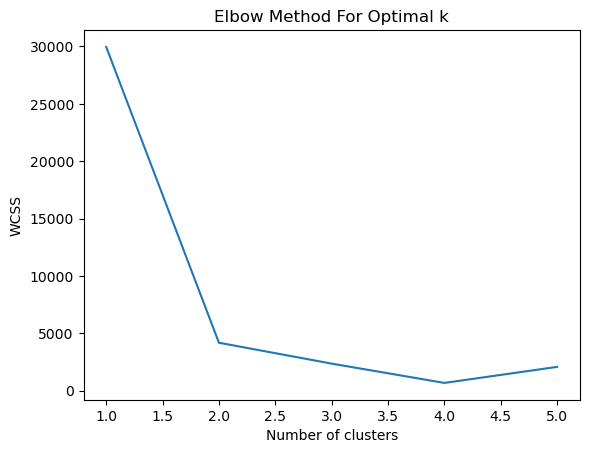

In [6]:
kmeans.find_appropriate_no_of_clusters(X, 5)

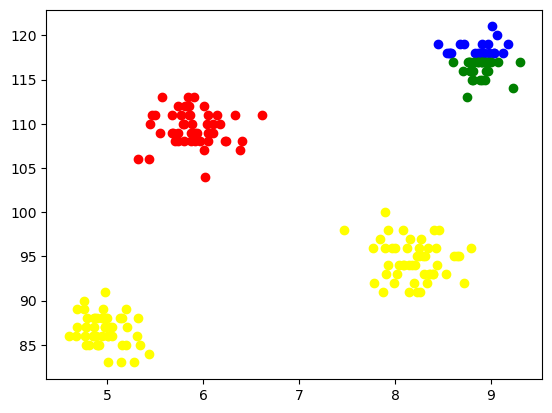

In [7]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')
plt.show()